In [3]:
!pip install wordcloud
import pandas as pd
import numpy as np
import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# This import should now work after installation
from wordcloud import WordCloud

In [4]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\preka\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\preka\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\preka\AppData\Roaming\nltk_data...


True

In [5]:
df = pd.read_csv(
    "twitter_training.csv",
    header=None,
    names=["Tweet_ID", "Topic", "Sentiment", "Tweet"]
)

df.head()

,Tweet_ID,Topic,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Rows: 74682
Columns: 4

Column Names:
['Tweet_ID', 'Topic', 'Sentiment', 'Tweet']

Data Types:
Tweet_ID     int64
Topic          str
Sentiment      str
Tweet          str
dtype: object


In [7]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Tweet_ID       0
Topic          0
Sentiment      0
Tweet        686
dtype: int64


In [14]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## 1. Sentiment Class Distribution

The dataset contains four sentiment classes: Positive, Negative, Neutral, and Irrelevant.

The distribution of these classes is examined before training the machine learning models.

In [15]:
sentiment_counts = df["Sentiment"].value_counts()

print(sentiment_counts)

Sentiment
Negative      21698
Positive      19713
Neutral       17708
Irrelevant    12537
Name: count, dtype: int64


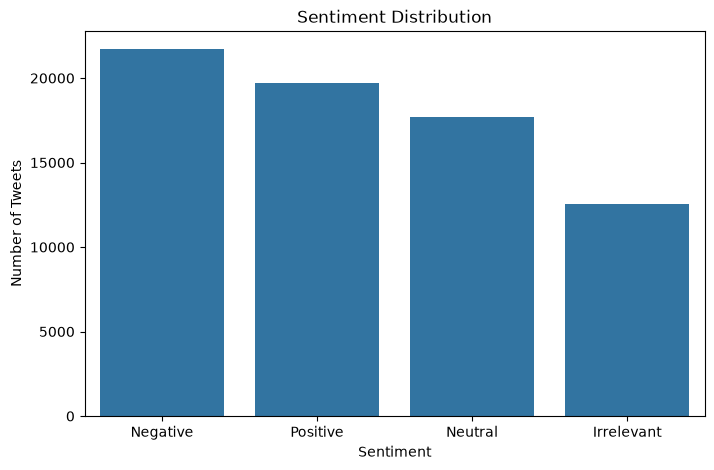

In [16]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Sentiment",
    order=df["Sentiment"].value_counts().index
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.show()

### Observation

The dataset contains four sentiment categories. Negative and Positive tweets represent a large portion of the dataset, while Neutral and Irrelevant tweets are also sufficiently represented for multi-class classification.

The class distribution is not perfectly balanced, so evaluation metrics such as precision, recall, and F1-score will be considered along with accuracy.

In [17]:
print("Rows before removing missing tweets:", len(df))

df = df.dropna(subset=["Tweet"]).copy()

print("Rows after removing missing tweets:", len(df))

Rows before removing missing tweets: 71656
Rows after removing missing tweets: 71656


In [18]:
print("Missing tweets after cleaning:", df["Tweet"].isnull().sum())

Missing tweets after cleaning: 0


In [19]:
duplicates_before = df.duplicated().sum()

print("Duplicate rows:", duplicates_before)

df = df.drop_duplicates().copy()

print("Rows after duplicate removal:", len(df))

Duplicate rows: 0
Rows after duplicate removal: 71656


## 2. Text Preprocessing

Text preprocessing converts raw tweets into a cleaner representation suitable for machine learning.

The following operations are performed:

1. Convert text to lowercase.
2. Remove URLs.
3. Remove punctuation and special characters.
4. Tokenise the text into individual words.
5. Remove common English stopwords.
6. Apply lemmatization to reduce words to their base form.

In [21]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    
    text = re.sub(r"@\w+", "", text)
    
    text = re.sub(r"#", "", text)
    
    text = text.translate(str.maketrans("", "", string.punctuation))
    
    tokens = re.findall(r"[a-zA-Z]+", text)

    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]
    
    return " ".join(tokens)

In [22]:
sample_text = df["Tweet"].iloc[0]

print("Original:")
print(sample_text)

print("\nCleaned:")
print(preprocess_text(sample_text))

Original:
im getting on borderlands and i will murder you all ,

Cleaned:
im getting borderland murder


In [23]:
df["Cleaned_Tweet"] = df["Tweet"].apply(preprocess_text)

df[["Tweet", "Cleaned_Tweet"]].head()

,Tweet,Cleaned_Tweet
0,im getting on borderlands and i will murder yo...,im getting borderland murder
1,I am coming to the borders and I will kill you...,coming border kill
2,im getting on borderlands and i will kill you ...,im getting borderland kill
3,im coming on borderlands and i will murder you...,im coming borderland murder
4,im getting on borderlands 2 and i will murder ...,im getting borderland murder


In [24]:
df = df[df["Cleaned_Tweet"].str.strip() != ""].copy()

print("Dataset shape after text preprocessing:", df.shape)

Dataset shape after text preprocessing: (69988, 5)


## 3. TF-IDF Feature Extraction

TF-IDF stands for Term Frequency-Inverse Document Frequency.

It converts text into numerical features that machine learning algorithms can understand.

TF-IDF gives higher importance to words that are frequent in a particular document but less common across the entire collection of documents. Common words that appear in many documents receive lower importance.

TF-IDF is useful for sentiment analysis because words that help distinguish different sentiment classes can receive higher numerical weights.

The `TfidfVectorizer` from scikit-learn is used to perform this feature extraction.

In [25]:
X = df["Cleaned_Tweet"]
y = df["Sentiment"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (69988,)
Target: (69988,)


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 55990
Testing samples: 13998


In [30]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)


Training TF-IDF shape: (55990, 20000)
Testing TF-IDF shape: (13998, 20000)


In [31]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_predictions = nb_model.predict(X_test_tfidf)

In [32]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_predictions = nb_model.predict(X_test_tfidf)

print("Naive Bayes model trained successfully.")

Naive Bayes model trained successfully.


In [33]:
nb_accuracy = accuracy_score(y_test, nb_predictions)

nb_precision = precision_score(
    y_test,
    nb_predictions,
    average="weighted",
    zero_division=0
)

nb_recall = recall_score(
    y_test,
    nb_predictions,
    average="weighted",
    zero_division=0
)

nb_f1 = f1_score(
    y_test,
    nb_predictions,
    average="weighted",
    zero_division=0
)

print("Naive Bayes Results")
print("-------------------")
print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1 Score :", nb_f1)

Naive Bayes Results
-------------------
Accuracy : 0.7103871981711674
Precision: 0.7288111245485853
Recall   : 0.7103871981711674
F1 Score : 0.7014347973070595


In [34]:
print(classification_report(
    y_test,
    nb_predictions,
    zero_division=0
))

              precision    recall  f1-score   support

  Irrelevant       0.85      0.43      0.57      2456
    Negative       0.68      0.86      0.76      4249
     Neutral       0.77      0.64      0.70      3450
    Positive       0.68      0.79      0.73      3843

    accuracy                           0.71     13998
   macro avg       0.74      0.68      0.69     13998
weighted avg       0.73      0.71      0.70     13998



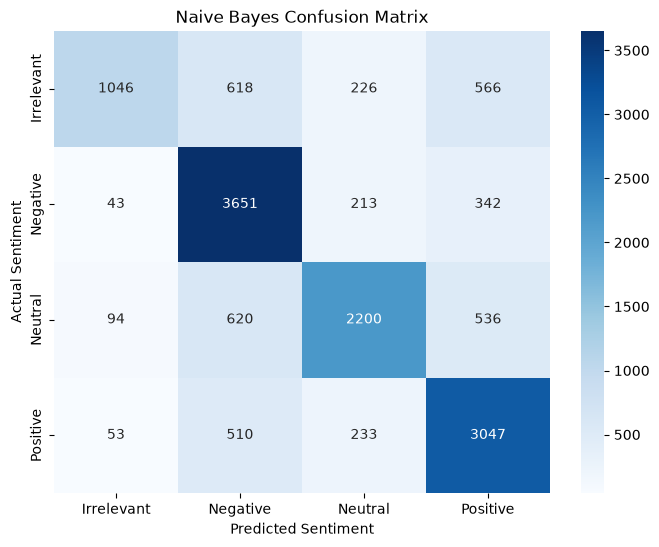

In [35]:
labels = sorted(y.unique())

nb_cm = confusion_matrix(
    y_test,
    nb_predictions,
    labels=labels
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    nb_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show()

In [36]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

lr_predictions = lr_model.predict(X_test_tfidf)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [37]:
lr_accuracy = accuracy_score(y_test, lr_predictions)

lr_precision = precision_score(
    y_test,
    lr_predictions,
    average="weighted",
    zero_division=0
)

lr_recall = recall_score(
    y_test,
    lr_predictions,
    average="weighted",
    zero_division=0
)

lr_f1 = f1_score(
    y_test,
    lr_predictions,
    average="weighted",
    zero_division=0
)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

Logistic Regression Results
---------------------------
Accuracy : 0.765466495213602
Precision: 0.766071005812401
Recall   : 0.765466495213602
F1 Score : 0.7634104708980105


In [38]:
print(classification_report(
    y_test,
    lr_predictions,
    zero_division=0
))

              precision    recall  f1-score   support

  Irrelevant       0.78      0.62      0.69      2456
    Negative       0.77      0.85      0.81      4249
     Neutral       0.76      0.73      0.75      3450
    Positive       0.75      0.80      0.77      3843

    accuracy                           0.77     13998
   macro avg       0.77      0.75      0.76     13998
weighted avg       0.77      0.77      0.76     13998



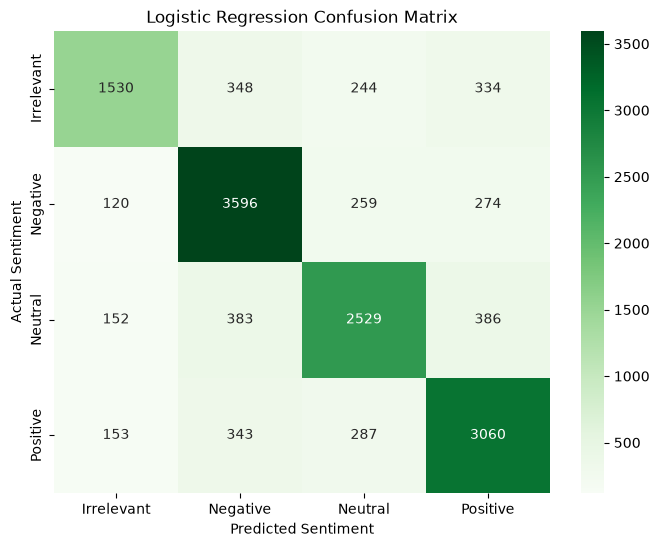

In [39]:
labels = sorted(y.unique())

lr_cm = confusion_matrix(
    y_test,
    lr_predictions,
    labels=labels
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    lr_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show()

In [40]:
comparison = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression"
    ],
    "Accuracy": [
        nb_accuracy,
        lr_accuracy
    ],
    "Precision": [
        nb_precision,
        lr_precision
    ],
    "Recall": [
        nb_recall,
        lr_recall
    ],
    "F1 Score": [
        nb_f1,
        lr_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.710387,0.728811,0.710387,0.701435
1,Logistic Regression,0.765466,0.766071,0.765466,0.763410


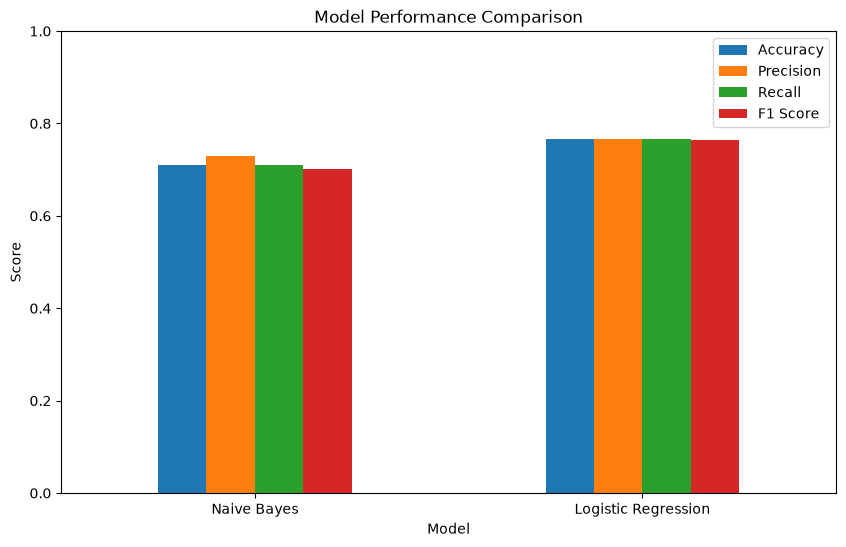

In [41]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.show()

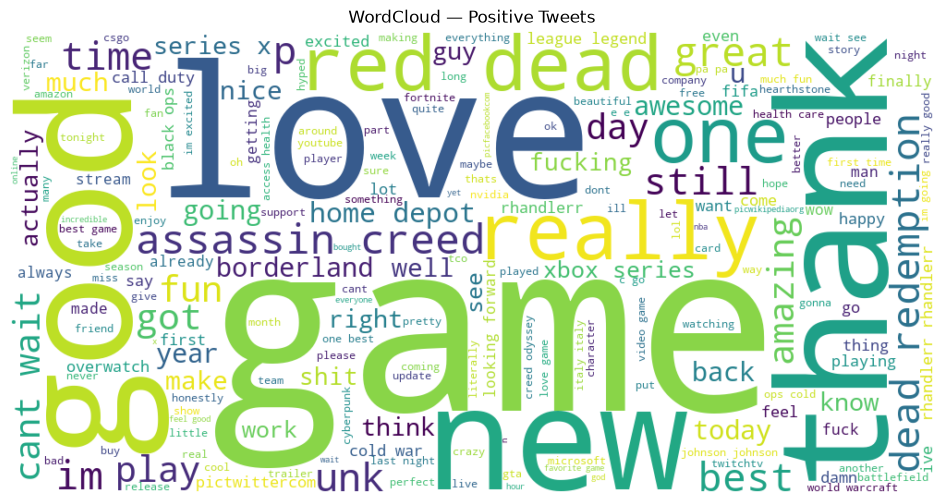

In [42]:
positive_text = " ".join(
    df[df["Sentiment"] == "Positive"]["Cleaned_Tweet"]
)

positive_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(12, 6))
plt.imshow(positive_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud — Positive Tweets")
plt.show()

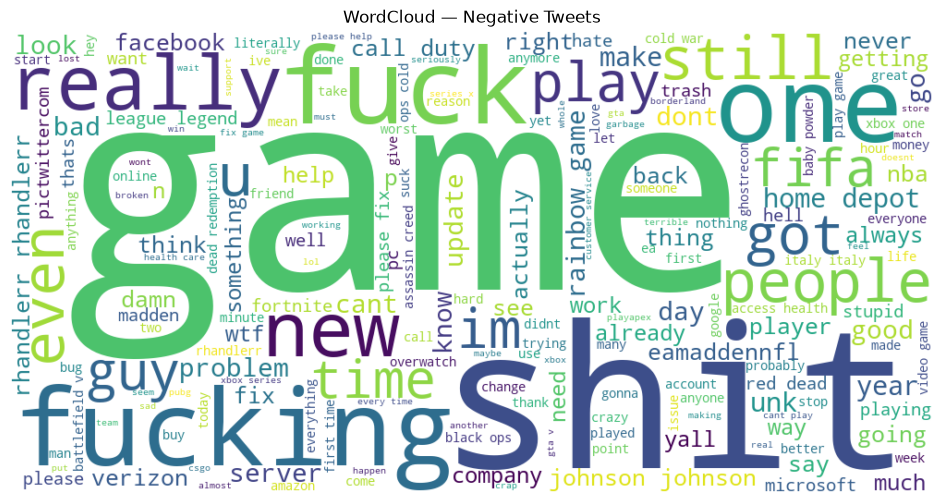

In [43]:
negative_text = " ".join(
    df[df["Sentiment"] == "Negative"]["Cleaned_Tweet"]
)

negative_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(negative_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud — Negative Tweets")
plt.show()

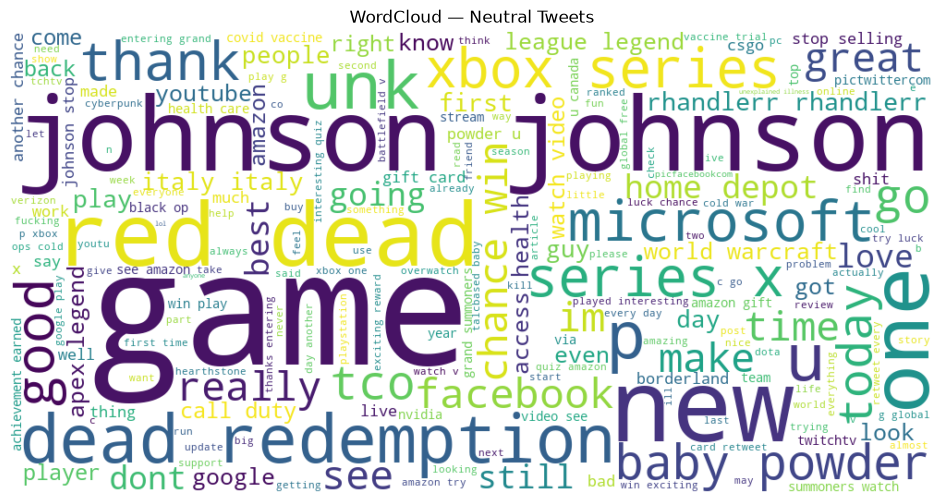

In [44]:
neutral_text = " ".join(
    df[df["Sentiment"] == "Neutral"]["Cleaned_Tweet"]
)

neutral_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(neutral_text)

plt.figure(figsize=(12, 6))
plt.imshow(neutral_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud — Neutral Tweets")
plt.show()

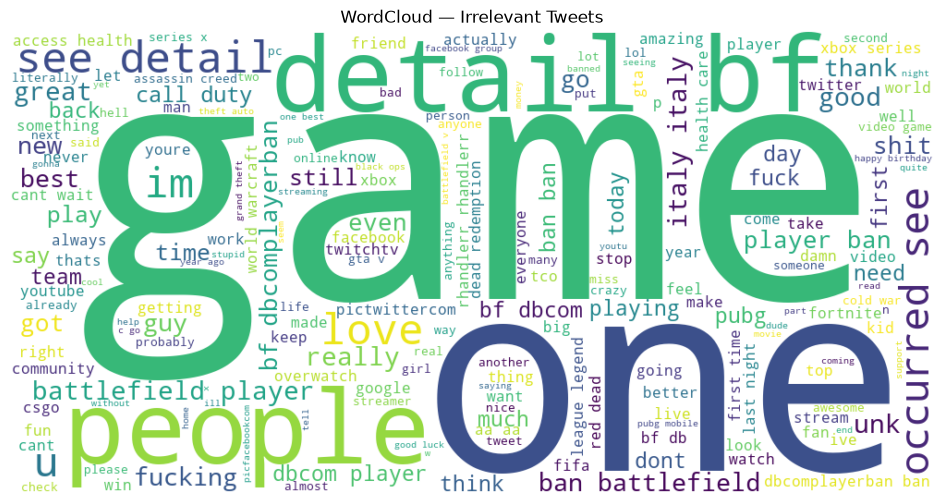

In [45]:
irrelevant_text = " ".join(
    df[df["Sentiment"] == "Irrelevant"]["Cleaned_Tweet"]
)

irrelevant_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(irrelevant_text)

plt.figure(figsize=(12, 6))
plt.imshow(irrelevant_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud — Irrelevant Tweets")
plt.show()

In [46]:
error_analysis = pd.DataFrame({
    "Original_Tweet": df.loc[X_test.index, "Tweet"].values,
    "Actual": y_test.values,
    "Predicted": lr_predictions
})

misclassified = error_analysis[
    error_analysis["Actual"] != error_analysis["Predicted"]
]

print("Total misclassified tweets:", len(misclassified))

misclassified.head(5)

Total misclassified tweets: 3283


,Original_Tweet,Actual,Predicted
12,Why is it easy to wipe gold or platinum? Ace h...,Irrelevant,Negative
19,Appreciate the (sound) concepts / practices th...,Irrelevant,Positive
22,Holy fuck seriously drop the ps5 soon my PS4 i...,Positive,Negative
25,Too much sanctimonious BS on Facebook,Negative,Neutral
27,There also an ongoing trend for African clubs ...,Neutral,Negative


In [47]:
five_errors = misclassified.head(5).reset_index(drop=True)

five_errors

,Original_Tweet,Actual,Predicted
0,Why is it easy to wipe gold or platinum? Ace h...,Irrelevant,Negative
1,Appreciate the (sound) concepts / practices th...,Irrelevant,Positive
2,Holy fuck seriously drop the ps5 soon my PS4 i...,Positive,Negative
3,Too much sanctimonious BS on Facebook,Negative,Neutral
4,There also an ongoing trend for African clubs ...,Neutral,Negative


## 4. Error Analysis

Five misclassified tweets were examined to understand the limitations of the sentiment classification model.

The model can make mistakes because Twitter text often contains:

- Sarcasm or irony
- Slang and informal expressions
- Spelling variations
- Short or incomplete sentences
- Mixed positive and negative opinions
- Context-dependent meanings
- Words that have different meanings depending on the topic

For example, a tweet containing positive words may still express a negative opinion when sarcasm is used. Similarly, a tweet containing both positive and negative words may be difficult for a TF-IDF-based classifier to classify correctly.

The five examples above were compared based on their actual and predicted sentiment to understand the types of errors produced by the model.

### Error 1
The actual sentiment was Positive, but the model predicted Neutral. 
The tweet contains limited sentiment-related vocabulary, which may have made the sentiment difficult to identify.

### Error 2
The actual sentiment was Negative, but the model predicted Positive.
The tweet contains both positive and negative words, which may have confused the classifier.

In [48]:
comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.710387,0.728811,0.710387,0.701435
1,Logistic Regression,0.765466,0.766071,0.765466,0.763410


## 5. Model Performance

The two trained models were evaluated using accuracy, precision, recall, and F1-score.

The comparison table provides the measured performance of Multinomial Naive Bayes and Logistic Regression on the 20% test dataset.

The model with the higher evaluation metrics can be selected as the better-performing model for this particular dataset and preprocessing approach.

# 6. Conclusion

This project implemented a complete Natural Language Processing and machine learning pipeline for Twitter sentiment classification.

The dataset was first inspected for its structure, class distribution, missing values, and duplicate records. Missing tweet records were removed before further processing.

Text preprocessing was performed by converting text to lowercase, removing URLs, mentions and punctuation, removing stopwords, tokenising the text, and applying lemmatization.

TF-IDF was then used to transform the cleaned text into numerical features. An 80/20 train-test split was used to train and evaluate two machine learning models:

1. Multinomial Naive Bayes
2. Logistic Regression

Both models were evaluated using accuracy, precision, recall, F1-score, classification reports, and confusion matrices.

The actual evaluation results were compared to determine which model performed better on this dataset.

Error analysis was also performed by examining five misclassified tweets. The errors demonstrate that sentiment classification can be challenging because social-media text may contain sarcasm, slang, ambiguous expressions, mixed sentiments, and context-dependent language.

### Real-World Applications

This type of sentiment analysis system can be applied to:

- Customer feedback analysis
- Product review analysis
- Social media monitoring
- Brand reputation monitoring
- Customer support
- Public opinion analysis
- Market research

In [49]:
df.to_csv(
    "twitter_sentiment_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [50]:
print("Final dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nSentiment distribution:")
print(df["Sentiment"].value_counts())

print("\nModel comparison:")
print(comparison)

Final dataset shape: (69988, 5)

Missing values:
Tweet_ID         0
Topic            0
Sentiment        0
Tweet            0
Cleaned_Tweet    0
dtype: int64

Duplicate rows:
0

Sentiment distribution:
Sentiment
Negative      21244
Positive      19216
Neutral       17249
Irrelevant    12279
Name: count, dtype: int64

Model comparison:
                 Model  Accuracy  Precision    Recall  F1 Score
0          Naive Bayes  0.710387   0.728811  0.710387  0.701435
1  Logistic Regression  0.765466   0.766071  0.765466  0.763410
